J’ai choisi cette image car elle contient plusieurs niveaux de gris, ce qui permet d’observer clairement les transformations appliquées. Elle présente aussi des zones sombres, des zones claires et des détails intermédiaires, ce qui la rend intéressante à analyser.

La transformation qui me semble la plus utile est le seuillage, car elle permet de faire ressortir certaines zones importantes de l’image. En simplifiant les intensités, on distingue mieux certains contours et certaines parties visuelles.

L’image affichée correspond à une matrice numérique où chaque valeur représente l’intensité d’un pixel. Cela montre qu’une image n’est pas seulement un élément visuel, mais aussi un ensemble de données que l’on peut manipuler avec Python.

L’histogramme permet de mieux comprendre comment les intensités sont réparties dans l’image. Il aide à voir si l’image contient beaucoup de tons foncés, clairs ou intermédiaires, et il permet aussi de comparer les effets des transformations.

En observant les résultats, on remarque que la transformation binaire est celle qui modifie le plus les intensités. En effet, elle réduit toutes les valeurs possibles à seulement deux niveaux : 0 et 255.

Le dataframe Pandas permet aussi de résumer les résultats numériques de manière claire. Grâce aux colonnes comme la moyenne et l’écart-type, il devient plus facile de comparer les images transformées.

Ce travail m’a permis de comprendre qu’une image en niveaux de gris peut être explorée comme une matrice NumPy, transformée avec des opérations numériques, puis analysée visuellement et statistiquement.

In [30]:
df_compare = df[["Image", "Moyenne", "Ecart-type"]]
df_compare

,Image,Moyenne,Ecart-type
0,Original,129.060726,73.644847
1,Zone,123.253175,76.083142
2,Bright,108.504375,79.944815
3,Dark,143.883575,67.508555
4,Threshold,124.817350,102.507582
5,Binary,141.117000,126.770767


In [29]:
df_transfo = df[df["Image"] != "Original"]
df_transfo

,Image,Lignes,Colonnes,Max,Moyenne,Ecart-type
1,Zone,200,200,255,123.253175,76.083142
2,Bright,200,200,255,108.504375,79.944815
3,Dark,200,200,255,143.883575,67.508555
4,Threshold,200,200,255,124.817350,102.507582
5,Binary,200,200,255,141.117000,126.770767


In [28]:
df.drop(columns=["Min"], inplace=True)
df

,Image,Lignes,Colonnes,Max,Moyenne,Ecart-type
0,Original,512,512,255,129.060726,73.644847
1,Zone,200,200,255,123.253175,76.083142
2,Bright,200,200,255,108.504375,79.944815
3,Dark,200,200,255,143.883575,67.508555
4,Threshold,200,200,255,124.817350,102.507582
5,Binary,200,200,255,141.117000,126.770767


In [27]:
df.rename(columns={"Nom": "Image"}, inplace=True)
df

,Image,Lignes,Colonnes,Min,Max,Moyenne,Ecart-type
0,Original,512,512,0,255,129.060726,73.644847
1,Zone,200,200,3,255,123.253175,76.083142
2,Bright,200,200,0,255,108.504375,79.944815
3,Dark,200,200,0,255,143.883575,67.508555
4,Threshold,200,200,0,255,124.817350,102.507582
5,Binary,200,200,0,255,141.117000,126.770767


In [26]:
data = {
    "Nom": ["Original", "Zone", "Bright", "Dark", "Threshold", "Binary"],
    "Lignes": [
        image.shape[0],
        zone.shape[0],
        bright.shape[0],
        dark.shape[0],
        threshold.shape[0],
        binary.shape[0]
    ],
    "Colonnes": [
        image.shape[1],
        zone.shape[1],
        bright.shape[1],
        dark.shape[1],
        threshold.shape[1],
        binary.shape[1]
    ],
    "Min": [
        image.min(),
        zone.min(),
        bright.min(),
        dark.min(),
        threshold.min(),
        binary.min()
    ],
    "Max": [
        image.max(),
        zone.max(),
        bright.max(),
        dark.max(),
        threshold.max(),
        binary.max()
    ],
    "Moyenne": [
        image.mean(),
        zone.mean(),
        bright.mean(),
        dark.mean(),
        threshold.mean(),
        binary.mean()
    ],
    "Ecart-type": [
        image.std(),
        zone.std(),
        bright.std(),
        dark.std(),
        threshold.std(),
        binary.std()
    ]
}

df = pd.DataFrame(data)
df

,Nom,Lignes,Colonnes,Min,Max,Moyenne,Ecart-type
0,Original,512,512,0,255,129.060726,73.644847
1,Zone,200,200,3,255,123.253175,76.083142
2,Bright,200,200,0,255,108.504375,79.944815
3,Dark,200,200,0,255,143.883575,67.508555
4,Threshold,200,200,0,255,124.817350,102.507582
5,Binary,200,200,0,255,141.117000,126.770767


L’histogramme représente la distribution des intensités des pixels.
Dans l’image originale, les valeurs sont réparties sur plusieurs niveaux de gris.
Dans l’image binaire, les valeurs sont concentrées uniquement sur 0 et 255.
Cela montre que la transformation binaire simplifie fortement l’image.

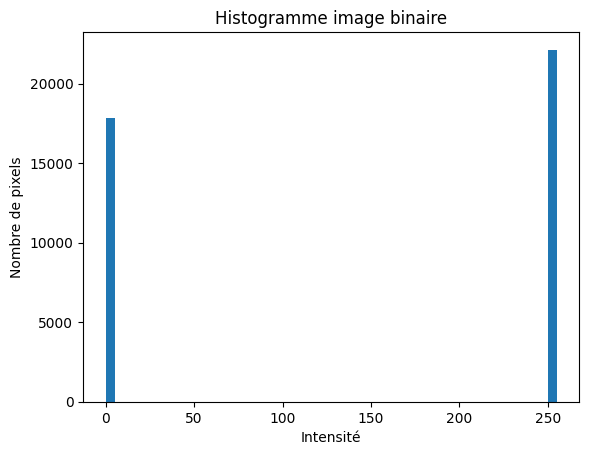

In [25]:
plt.hist(binary.flatten(), bins=50)
plt.title("Histogramme image binaire")
plt.xlabel("Intensité")
plt.ylabel("Nombre de pixels")
plt.show()

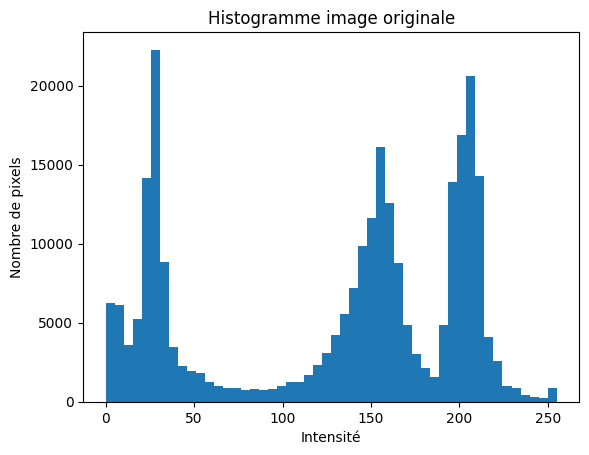

In [24]:
plt.hist(image.flatten(), bins=50)
plt.title("Histogramme image originale")
plt.xlabel("Intensité")
plt.ylabel("Nombre de pixels")
plt.show()

La transformation éclaircie augmente les intensités des pixels.
La transformation assombrie diminue les intensités.
Le seuillage permet de mettre en évidence certaines zones.
L’image binaire simplifie l’image en deux valeurs (0 et 255).

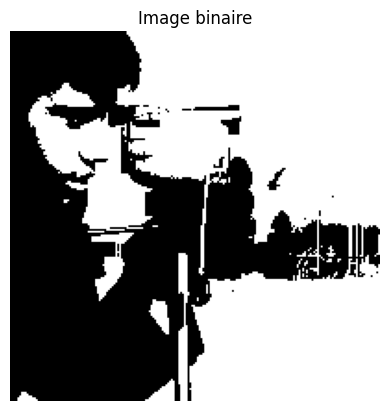

In [23]:
binary = np.where(zone_copy > 128, 255, 0)

plt.imshow(binary, cmap='gray')
plt.title("Image binaire")
plt.axis('off')
plt.show()

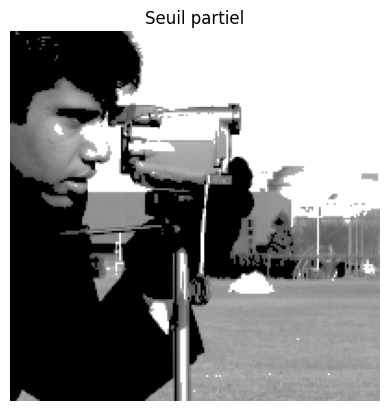

In [22]:
threshold = zone_copy.copy()

threshold[threshold < 80] = 0
threshold[threshold > 180] = 255

plt.imshow(threshold, cmap='gray')
plt.title("Seuil partiel")
plt.axis('off')
plt.show()

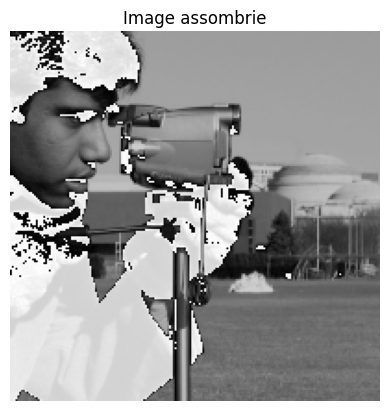

In [21]:
dark = zone_copy - 50
dark = np.clip(dark, 0, 255)

plt.imshow(dark, cmap='gray')
plt.title("Image assombrie")
plt.axis('off')
plt.show()

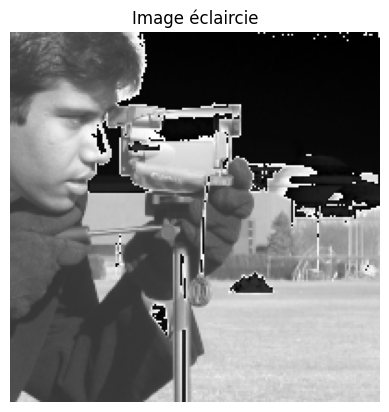

In [20]:
bright = zone_copy + 50
bright = np.clip(bright, 0, 255)

plt.imshow(bright, cmap='gray')
plt.title("Image éclaircie")
plt.axis('off')
plt.show()

Il est préférable de travailler sur une copie pour éviter de modifier l’image originale lors des transformations.

In [12]:
print("Dimensions :", zone.shape)

Dimensions : (200, 200)


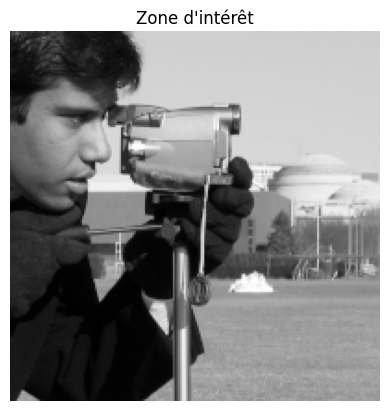

In [13]:
plt.imshow(zone, cmap='gray')
plt.title("Zone d'intérêt")
plt.axis('off')
plt.show()

In [14]:
zone_copy = zone.copy()

In [15]:
zone = image[100:300, 200:400]

L’image est représentée sous forme de matrice 2D.
Chaque valeur correspond à l’intensité d’un pixel.
Les valeurs faibles représentent les zones sombres et les valeurs élevées les zones claires.

In [16]:
print("Shape :", image.shape)
print("Type :", image.dtype)
print("Min :", image.min())
print("Max :", image.max())

Shape : (512, 512)
Type : uint8
Min : 0
Max : 255


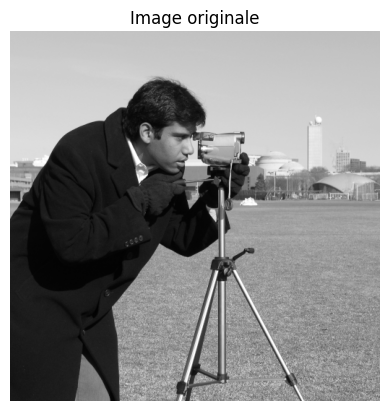

In [17]:
plt.imshow(image, cmap='gray')
plt.title("Image originale")
plt.axis('off')
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import data

In [19]:
image = data.camera()